In [5]:
!pip install --upgrade torch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/887.9 MB 17.3 MB/s eta 0:00:52Downloading torch-2.8.0-cp312-cp312-manylinux_2_28_x86_64.whl (887.9 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 2.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.9/887.9 MB 2.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/594.3 MB ? eta -:--:--Downloading nvidia_cublas_cu12-12.8.4.1-py3-none-manylinux_2_27_x86_64.whl (594.3 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 2.2 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/10.2 MB ? eta -:--:--Downloading nvidia_cuda_cupti_cu12-12.8.90-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (10.2 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 9.0 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 9.0 MB/s eta 0:0

In [4]:

from PIL import Image, ImageOps
import torch, os, random
from diffusers import StableDiffusionImg2ImgPipeline

#
# --- User options ---
IMAGE_PATH = "./image.png"  # leave empty to upload
OUT_DIR = "./pose_out"
NUM_PER_POSE = 1
STRENGTH = 0.45
GUIDANCE = 7.5
SEED = 123
MODEL_ID = "JCTN/Arc2Face"
IMG_SIZE = 768


# --- Helper: pad & resize square ---
def center_pad_resize(img: Image.Image, target=768):
    img = ImageOps.exif_transpose(img).convert("RGB")
    w, h = img.size
    side = max(w, h)
    bg = Image.new("RGB", (side, side), (0, 0, 0))
    bg.paste(img, ((side - w)//2, (side - h)//2))
    return bg.resize((target, target), Image.LANCZOS)

POSE_PROMPTS = [
    "portrait of the same person, head turned slightly left",
    "portrait of the same person, head turned slightly right",
    "portrait of the same person, head tilted up slightly",
    "portrait of the same person, head tilted down slightly",
    "portrait of the same person, profile view left side",
    "portrait of the same person, profile view right side"
]
NEG_PROMPT = "blurry, deformed, artifacts, low quality, watermark, text, extra limbs"

# --- Load image ---
base = center_pad_resize(Image.open(IMAGE_PATH), IMG_SIZE)

# --- Pipeline ---
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
pipe = StableDiffusionImg2ImgPipeline.from_pretrained(
    MODEL_ID, torch_dtype=dtype, safety_checker=None
).to(device)

os.makedirs(OUT_DIR, exist_ok=True)
if SEED is not None: torch.manual_seed(SEED)

# --- Generate ---
for i, prompt in enumerate(POSE_PROMPTS):
    for k in range(NUM_PER_POSE):
        seed = (SEED + i*100 + k) if SEED else random.randint(0, 1e9)
        generator = torch.Generator(device=device).manual_seed(seed)
        result = pipe(
            prompt=prompt,
            image=base,
            strength=STRENGTH,
            guidance_scale=GUIDANCE,
            negative_prompt=NEG_PROMPT,
            num_inference_steps=30,
            generator=generator,
        )
        outpath = os.path.join(OUT_DIR, f"pose_{i:02d}_{k:02d}_seed{seed}.png")
        result.images[0].save(outpath)
        print("✔ saved:", outpath)

print(f"\n✅ done. check: {OUT_DIR}")


EntryNotFoundError: 404 Client Error. (Request ID: Root=1-68ed329e-4f4c82283f2585883581a384;d243590a-7839-4e20-8017-520036cb58ac)

Entry Not Found for url: https://huggingface.co/JCTN/Arc2Face/resolve/main/model_index.json.

# FaceNet Embedding Generation Test

This notebook demonstrates how to use the FaceNet model to convert a face image into embeddings.

In [1]:
import sys
import os
import torch
from PIL import Image
from torchvision import transforms
import numpy as np

# Add FaceNet directory to path
sys.path.append('../FaceNet')

from networks.models_facenet import MobileFaceNet

print("✓ Imports successful")

✓ Imports successful


## Load the Pre-trained Model

In [2]:
# Set device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Initialize the model
embedding_size = 512
backbone = MobileFaceNet(embedding_size=embedding_size).to(device)

# Load the best checkpoint
checkpoint_path = '../FaceNet/mobilefacenet_arcface/best_model_epoch43_acc100.00.pth'
checkpoint = torch.load(checkpoint_path, map_location=device)
backbone.load_state_dict(checkpoint['model_state_dict'])
backbone.eval()

print(f"✓ Model loaded from: {checkpoint_path}")
print(f"✓ Model trained for {checkpoint.get('epoch', 'unknown')} epochs")
print(f"✓ Embedding dimension: {embedding_size}")

Using device: cuda
✓ Model loaded from: ../FaceNet/mobilefacenet_arcface/best_model_epoch43_acc100.00.pth
✓ Model trained for 43 epochs
✓ Embedding dimension: 512


## Prepare Image Preprocessing Pipeline

In [3]:
# Define preprocessing transform (same as used in training)
preprocess = transforms.Compose([
    transforms.Resize((112, 112)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.31928780674934387, 0.2873991131782532, 0.25779902935028076],
        std=[0.19799138605594635, 0.20757903158664703, 0.21088403463363647]
    )
])

print("✓ Preprocessing pipeline ready")

✓ Preprocessing pipeline ready


## Load and Process Your Image

✓ Image loaded: ./image1.png
✓ Image shape after preprocessing: torch.Size([1, 3, 112, 112])


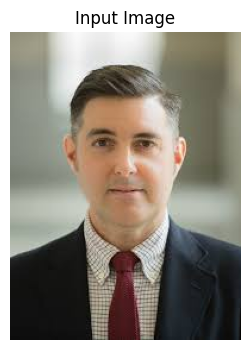

In [10]:
# Replace this path with your image path
image_path = "./image1.png"  # Change this to your actual image path

# Check if image exists
if not os.path.exists(image_path):
    print(f"⚠️  Image not found at: {image_path}")
    print("Please update the 'image_path' variable with the correct path to your image")
else:
    # Load and preprocess the image
    img = Image.open(image_path).convert('RGB')
    img_tensor = preprocess(img).unsqueeze(0).to(device)
    
    print(f"✓ Image loaded: {image_path}")
    print(f"✓ Image shape after preprocessing: {img_tensor.shape}")
    
    # Display the image
    import matplotlib.pyplot as plt
    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image')
    plt.show()

## Generate Face Embedding

✓ Embedding generated!
✓ Embedding shape: (512,)
✓ Embedding dimension: 512

First 10 values of the embedding:
[-0.00952223 -0.02170516  0.00174518 -0.0269238   0.01982232 -0.05683759
  0.02009005  0.08921454 -0.03781812  0.03232493]

Embedding statistics:
  - Mean: -0.002018
  - Std: 0.044148
  - Min: -0.148456
  - Max: 0.175229


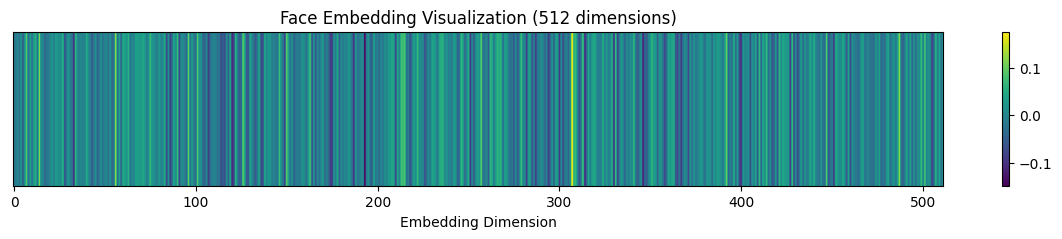

In [7]:
image_path2 = "./image.png"
img = Image.open(image_path2).convert('RGB')
img_tensor = preprocess(img).unsqueeze(0).to(device)
if os.path.exists(image_path2):
    # Generate embedding
    with torch.no_grad():
        embedding = backbone(img_tensor)
    
    # Convert to numpy for easier manipulation
    embedding_np = embedding.cpu().numpy().flatten()
    
    print(f"✓ Embedding generated!")
    print(f"✓ Embedding shape: {embedding_np.shape}")
    print(f"✓ Embedding dimension: {len(embedding_np)}")
    print(f"\nFirst 10 values of the embedding:")
    print(embedding_np[:10])
    print(f"\nEmbedding statistics:")
    print(f"  - Mean: {embedding_np.mean():.6f}")
    print(f"  - Std: {embedding_np.std():.6f}")
    print(f"  - Min: {embedding_np.min():.6f}")
    print(f"  - Max: {embedding_np.max():.6f}")
    
    # Visualize embedding as a heatmap
    plt.figure(figsize=(15, 2))
    plt.imshow(embedding_np.reshape(1, -1), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title('Face Embedding Visualization (512 dimensions)')
    plt.xlabel('Embedding Dimension')
    plt.yticks([])
    plt.show()

✓ Embedding generated!
✓ Embedding shape: (512,)
✓ Embedding dimension: 512

First 10 values of the embedding:
[-0.02503688 -0.01068966  0.00961023 -0.03661413  0.01125344 -0.03962103
  0.01840274  0.07243453 -0.05133211  0.0362527 ]

Embedding statistics:
  - Mean: -0.001050
  - Std: 0.044182
  - Min: -0.135906
  - Max: 0.164959


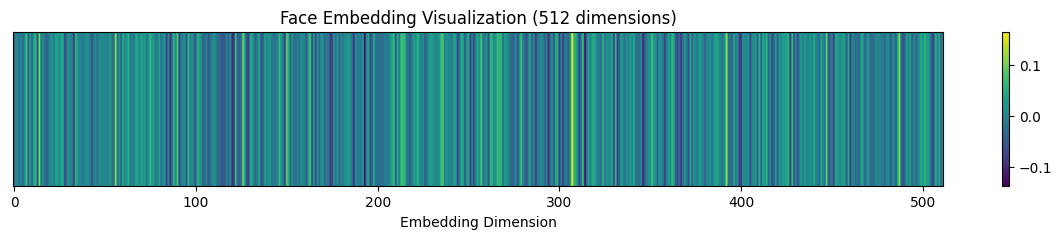

In [11]:
if os.path.exists(image_path):
    # Generate embedding
    with torch.no_grad():
        embedding = backbone(img_tensor)
    
    # Convert to numpy for easier manipulation
    embedding_np = embedding.cpu().numpy().flatten()
    
    print(f"✓ Embedding generated!")
    print(f"✓ Embedding shape: {embedding_np.shape}")
    print(f"✓ Embedding dimension: {len(embedding_np)}")
    print(f"\nFirst 10 values of the embedding:")
    print(embedding_np[:10])
    print(f"\nEmbedding statistics:")
    print(f"  - Mean: {embedding_np.mean():.6f}")
    print(f"  - Std: {embedding_np.std():.6f}")
    print(f"  - Min: {embedding_np.min():.6f}")
    print(f"  - Max: {embedding_np.max():.6f}")
    
    # Visualize embedding as a heatmap
    plt.figure(figsize=(15, 2))
    plt.imshow(embedding_np.reshape(1, -1), aspect='auto', cmap='viridis')
    plt.colorbar()
    plt.title('Face Embedding Visualization (512 dimensions)')
    plt.xlabel('Embedding Dimension')
    plt.yticks([])
    plt.show()

In [12]:
def img_to_embedding(image_path):
    if os.path.exists(image_path):
        # Load and preprocess the image
        img = Image.open(image_path).convert('RGB')
        img_tensor = preprocess(img).unsqueeze(0).to(device)
        
        # Generate embedding
        with torch.no_grad():
            embedding = backbone(img_tensor)
        
        # Convert to numpy for easier manipulation
        embedding_np = embedding.cpu().numpy().flatten()
        
        return embedding_np
    else:
        print(f"⚠️  Image not found at: {image_path}")
        return None
img1 = img_to_embedding("./image1.png")
img2 = img_to_embedding("./image.png")
#cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
similarity = cosine_similarity([img1], [img2])[0][0]
print(f"Cosine similarity between the two images: {similarity:.6f}")

Cosine similarity between the two images: 0.947020


## Optional: Save the Embedding

In [ ]:
if os.path.exists(image_path):
    # Save embedding to file
    output_path = "./face_embedding.npy"
    np.save(output_path, embedding_np)
    print(f"✓ Embedding saved to: {output_path}")
    
    # You can load it later with:
    # loaded_embedding = np.load(output_path)
    print("\nTo load this embedding later, use:")
    print("  loaded_embedding = np.load('face_embedding.npy')")

---
# Complete Face Detection + Embedding Pipeline

This section shows how to detect faces in an image first, then generate embeddings for each detected face.

In [ ]:
# First, install the face detection library
!pip install retina-face

In [13]:
import cv2
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Import the face detector from FaceNet utils
from utils.utils import RetinaFacePyPIAdapter

# Initialize face detector
face_detector = RetinaFacePyPIAdapter(threshold=0.5)
print("✓ Face detector initialized")

2025-10-14 20:15:05.712770: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


✓ Face detector initialized


In [ ]:
# Configure matplotlib to display images inline
%matplotlib inline
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100  # Better quality for inline display
print("✓ Matplotlib configured for inline display")

## Quick Image Preview (Debug)

## Detect Faces and Generate Embeddings

In [16]:
# Path to image with faces
test_image_path = "./image.png"  # Change this to your image

if not os.path.exists(test_image_path):
    print(f"⚠️  Image not found at: {test_image_path}")
else:
    # Load image with OpenCV
    img_bgr = cv2.imread(test_image_path)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    print(f"✓ Image loaded: {test_image_path}")
    print(f"✓ Image size: {img_rgb.shape}")
    
    # Detect faces
    print("\n🔍 Detecting faces...")
    face_bboxes = face_detector.detect_faces(img_bgr)
    
    print(f"✓ Found {len(face_bboxes)} face(s)")
    
    # Visualize detected faces
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img_rgb)
    
    # Store embeddings for each face
    face_embeddings = []
    
    for i, bbox in enumerate(face_bboxes):
        x1, y1, x2, y2 = bbox
        
        # Draw bounding box
        rect = Rectangle((x1, y1), x2-x1, y2-y1, 
                        linewidth=2, edgecolor='lime', facecolor='none')
        ax.add_patch(rect)
        ax.text(x1, y1-10, f'Face {i+1}', 
               color='lime', fontsize=12, weight='bold',
               bbox=dict(boxstyle='round,pad=0.3', facecolor='black', alpha=0.7))
        
        # Extract face region
        face_img = img_rgb[y1:y2, x1:x2]
        
        if face_img.shape[0] > 0 and face_img.shape[1] > 0:
            # Convert to PIL Image and preprocess
            face_pil = Image.fromarray(face_img)
            face_tensor = preprocess(face_pil).unsqueeze(0).to(device)
            
            # Generate embedding
            with torch.no_grad():
                embedding = backbone(face_tensor)
            
            embedding_np = embedding.cpu().numpy().flatten()
            face_embeddings.append({
                'face_id': i + 1,
                'bbox': bbox,
                'embedding': embedding_np
            })
            
            print(f"\n  Face {i+1}:")
            print(f"    - Location: ({x1}, {y1}) to ({x2}, {y2})")
            print(f"    - Size: {x2-x1}x{y2-y1} pixels")
            print(f"    - Embedding shape: {embedding_np.shape}")
            print(f"    - Embedding sample: {embedding_np[:5]}")
    
    ax.axis('off')
    plt.title(f'Detected Faces: {len(face_bboxes)}', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"\n✅ Successfully generated embeddings for {len(face_embeddings)} face(s)")

✓ Image loaded: ./image.png
✓ Image size: (246, 205, 3)

🔍 Detecting faces...
✓ Found 1 face(s)

  Face 1:
    - Location: (60, 37) to (146, 158)
    - Size: 86x121 pixels
    - Embedding shape: (512,)
    - Embedding sample: [-0.00255902 -0.01335111 -0.03574086 -0.02713137  0.04687769]

✅ Successfully generated embeddings for 1 face(s)


## Display Individual Detected Faces

In [17]:
if len(face_embeddings) > 0:
    # Display each detected face separately
    num_faces = len(face_embeddings)
    fig, axes = plt.subplots(1, num_faces, figsize=(4*num_faces, 4))
    
    if num_faces == 1:
        axes = [axes]
    
    for i, face_data in enumerate(face_embeddings):
        x1, y1, x2, y2 = face_data['bbox']
        face_crop = img_rgb[y1:y2, x1:x2]
        
        axes[i].imshow(face_crop)
        axes[i].axis('off')
        axes[i].set_title(f"Face {face_data['face_id']}", fontsize=12, weight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Show embedding visualization for first face
    if len(face_embeddings) > 0:
        first_face_emb = face_embeddings[0]['embedding']
        plt.figure(figsize=(15, 2))
        plt.imshow(first_face_emb.reshape(1, -1), aspect='auto', cmap='viridis')
        plt.colorbar()
        plt.title(f'Face 1 Embedding Visualization (512 dimensions)', fontsize=12, weight='bold')
        plt.xlabel('Embedding Dimension')
        plt.yticks([])
        plt.show()
else:
    print("No faces detected to display")

## Alternative: Simple Face Display

## Compare Embeddings (if multiple faces detected)

In [ ]:
if len(face_embeddings) >= 2:
    from sklearn.metrics.pairwise import cosine_similarity
    
    print("Face Similarity Matrix:")
    print("(Values closer to 1.0 = more similar faces)\n")
    
    # Create similarity matrix
    embeddings_matrix = np.array([f['embedding'] for f in face_embeddings])
    similarity_matrix = cosine_similarity(embeddings_matrix)
    
    # Display matrix
    for i in range(len(face_embeddings)):
        for j in range(len(face_embeddings)):
            if i < j:  # Only show upper triangle (avoid duplicates)
                sim = similarity_matrix[i][j]
                print(f"  Face {i+1} ↔ Face {j+1}: {sim:.4f}")
    
    # Visualize similarity matrix
    plt.figure(figsize=(8, 6))
    plt.imshow(similarity_matrix, cmap='RdYlGn', vmin=0, vmax=1)
    plt.colorbar(label='Cosine Similarity')
    plt.xticks(range(len(face_embeddings)), [f"Face {i+1}" for i in range(len(face_embeddings))])
    plt.yticks(range(len(face_embeddings)), [f"Face {i+1}" for i in range(len(face_embeddings))])
    plt.title('Face Similarity Matrix', fontsize=14, weight='bold')
    
    # Add text annotations
    for i in range(len(face_embeddings)):
        for j in range(len(face_embeddings)):
            plt.text(j, i, f'{similarity_matrix[i][j]:.3f}', 
                    ha='center', va='center', color='black', fontsize=10)
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Only {len(face_embeddings)} face(s) detected. Need at least 2 faces to compare.")

In [18]:
# Quick test to see if image displays
test_path = "./image.png"

if os.path.exists(test_path):
    # Method 1: Using PIL and matplotlib
    from PIL import Image
    import matplotlib.pyplot as plt
    
    img = Image.open(test_path)
    
    plt.figure(figsize=(6, 6))
    plt.imshow(img)
    plt.axis('off')
    plt.title('Original Image', fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Image size: {img.size}")
    print(f"✓ Image mode: {img.mode}")
else:
    print(f"❌ Image not found at: {test_path}")
    print(f"Current directory: {os.getcwd()}")
    print(f"Files in current directory: {os.listdir('.')}")

✓ Image size: (205, 246)
✓ Image mode: RGB


In [19]:
# Simple display of the image with detected faces
# This cell works standalone if variables exist from previous execution

try:
    if 'img_rgb' in dir() and 'face_bboxes' in dir():
        import matplotlib.pyplot as plt
        from matplotlib.patches import Rectangle
        
        # Create fresh figure
        fig, ax = plt.subplots(figsize=(10, 8))
        ax.imshow(img_rgb)
        
        # Draw rectangles for each detected face
        for i, bbox in enumerate(face_bboxes):
            x1, y1, x2, y2 = bbox
            rect = Rectangle((x1, y1), x2-x1, y2-y1, 
                           linewidth=3, edgecolor='lime', facecolor='none')
            ax.add_patch(rect)
            ax.text(x1, y1-10, f'Face {i+1}', 
                   color='lime', fontsize=14, weight='bold',
                   bbox=dict(boxstyle='round,pad=0.5', facecolor='black', alpha=0.8))
        
        ax.axis('off')
        ax.set_title(f'Image with {len(face_bboxes)} Detected Face(s)', 
                    fontsize=16, weight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        print(f"✓ Displayed image with {len(face_bboxes)} face(s)")
        
        # Also show cropped faces
        if len(face_bboxes) > 0:
            print("\nCropped Faces:")
            cols = min(3, len(face_bboxes))
            rows = (len(face_bboxes) + cols - 1) // cols
            
            fig2, axes = plt.subplots(rows, cols, figsize=(5*cols, 5*rows))
            if len(face_bboxes) == 1:
                axes = [axes]
            else:
                axes = axes.flatten()
            
            for i, bbox in enumerate(face_bboxes):
                x1, y1, x2, y2 = bbox
                face_crop = img_rgb[y1:y2, x1:x2]
                axes[i].imshow(face_crop)
                axes[i].axis('off')
                axes[i].set_title(f'Face {i+1}\n({x2-x1}x{y2-y1} pixels)', 
                                fontsize=12, weight='bold')
            
            # Hide unused subplots
            for i in range(len(face_bboxes), len(axes)):
                axes[i].axis('off')
            
            plt.tight_layout()
            plt.show()
    else:
        print("⚠️ Variables 'img_rgb' and 'face_bboxes' not found.")
        print("Please run the face detection cell first (the one starting with 'test_image_path = ...')")
        
except Exception as e:
    print(f"Error displaying image: {e}")
    import traceback
    traceback.print_exc()

✓ Displayed image with 1 face(s)

Cropped Faces:
